# Tips Dataset Exploratory Data Analysis (EDA)

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# optional for better visuals
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

In [2]:
# loading tips dataset from seaborn 
df = sns.load_dataset("tips")

## Studying Overall data 

In [3]:
# viewing top 5 rows of dataset 
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# checking rows and columns counting (how many rows and columns are there in the dataset)
df.shape

(244, 7)

In [5]:
# viewing all columns by their names 
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [6]:
# viewing information about the dataset 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [7]:
# statistical summary
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [8]:
# checking missing values
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [9]:
# checking duplicate values
df.duplicated().sum()

np.int64(1)

In [10]:
# remove duplicate rows
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

# Univarite Analysis

In [12]:
# statistical summary of total_bill
df['total_bill'].describe()


count    243.000000
mean      19.813868
std        8.910071
min        3.070000
25%       13.380000
50%       17.810000
75%       24.175000
max       50.810000
Name: total_bill, dtype: float64

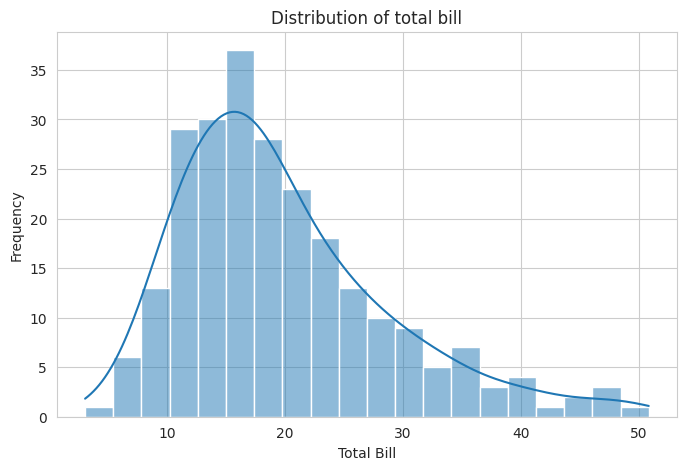

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['total_bill'], bins=20, kde=True)
plt.title("Distribution of total bill")
plt.xlabel('Total Bill')
plt.ylabel('Frequency')
plt.show()

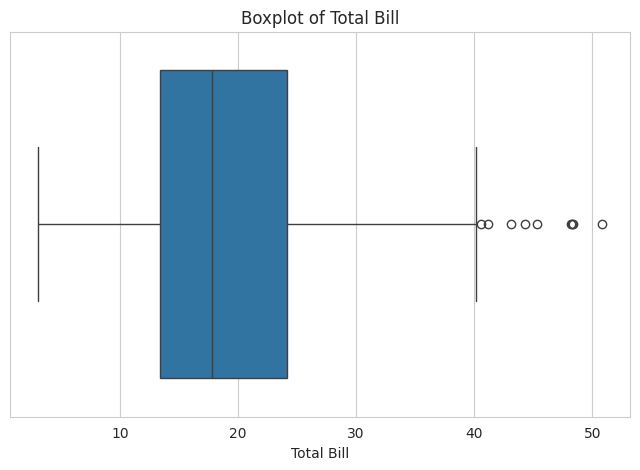

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["total_bill"])
plt.title("Boxplot of Total Bill")
plt.xlabel("Total Bill")
plt.show()

In [15]:
# Statistical summary of tip column
df['tip'].describe()

count    243.000000
mean       3.002387
std        1.385002
min        1.000000
25%        2.000000
50%        2.920000
75%        3.575000
max       10.000000
Name: tip, dtype: float64

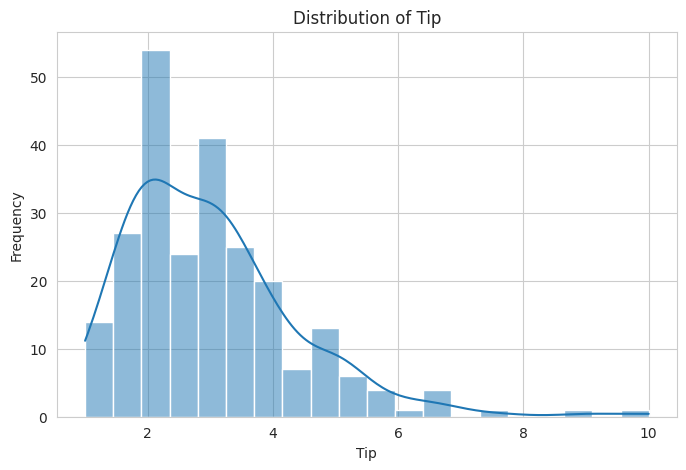

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['tip'], bins=20, kde=True)
plt.title("Distribution of Tip")
plt.xlabel('Tip')
plt.ylabel("Frequency")
plt.show()

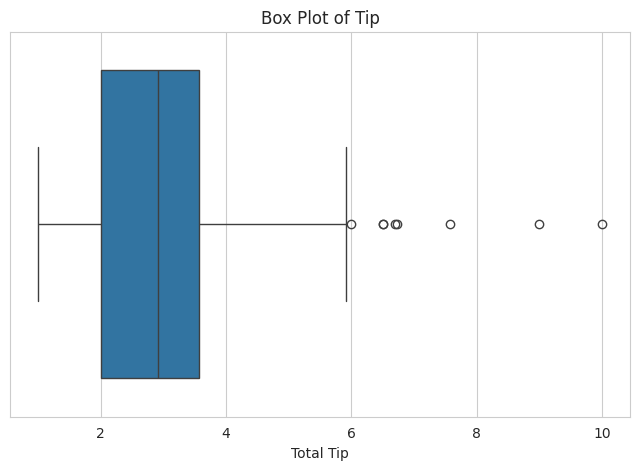

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["tip"])
plt.title("Box Plot of Tip")
plt.xlabel("Total Tip")
plt.show()


## Doing Categorical Analysis

In [18]:
# Analysis of Sex Column
df["sex"].value_counts() # Counting categories of sex

sex
Male      157
Female     86
Name: count, dtype: int64

In [19]:
# checking Percentages of categories of sex
df['sex'].value_counts(normalize=True) * 100 

sex
Male      64.609053
Female    35.390947
Name: proportion, dtype: float64

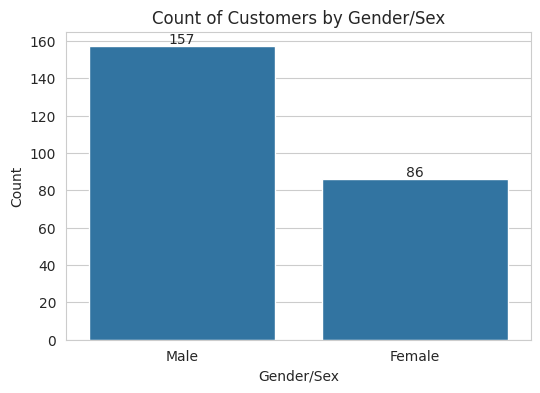

In [25]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x="sex", data=df)
plt.title("Count of Customers by Gender/Sex")
plt.xlabel("Gender/Sex")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [21]:
# Analysis of smoker Column
df['smoker'].value_counts()

smoker
No     151
Yes     92
Name: count, dtype: int64

In [22]:
df["smoker"].value_counts(normalize=True) * 100

smoker
No     62.139918
Yes    37.860082
Name: proportion, dtype: float64

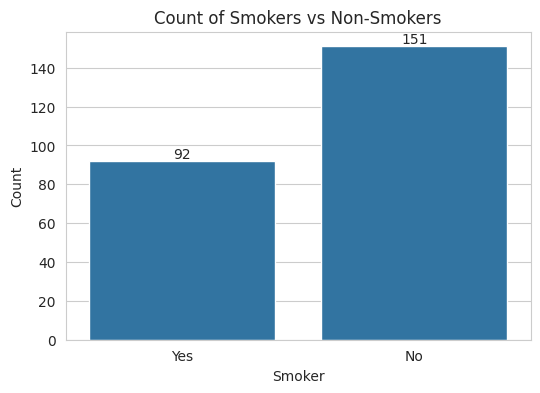

In [28]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='smoker' , data=df)
plt.title("Count of Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Count")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [26]:
# Analysis of day Column
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    61
Fri     19
Name: count, dtype: int64

In [27]:
df["day"].value_counts(normalize=True) * 100

day
Sat     35.802469
Sun     31.275720
Thur    25.102881
Fri      7.818930
Name: proportion, dtype: float64

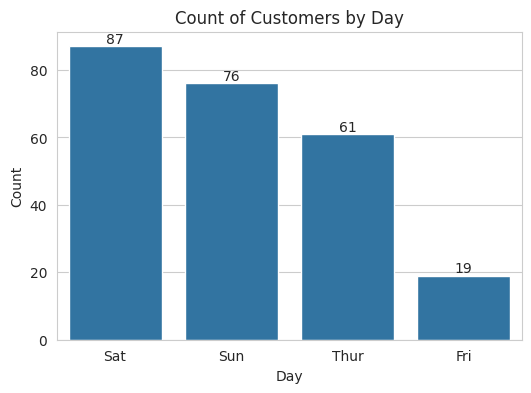

In [31]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='day', data=df, order=df['day'].value_counts().index)
plt.title("Count of Customers by Day")
plt.xlabel('Day')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [32]:
# Analysis of time Column
df['time'].value_counts()

time
Dinner    176
Lunch      67
Name: count, dtype: int64

In [33]:
df["time"].value_counts(normalize=True) * 100

time
Dinner    72.427984
Lunch     27.572016
Name: proportion, dtype: float64

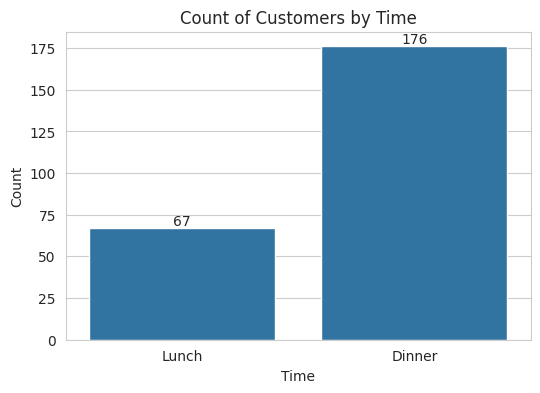

In [34]:
plt.figure(figsize=(6,4))
ax = sns.countplot(x='time', data=df)
plt.title("Count of Customers by Time")
plt.xlabel('Time')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

# BIVARIATE ANALYSIS

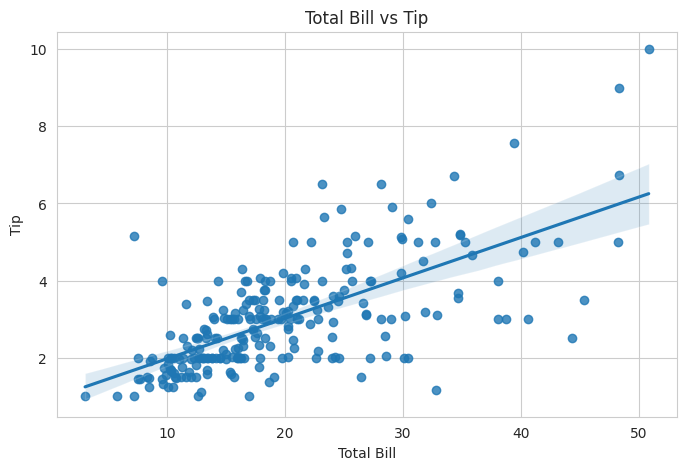

In [40]:
# Checking the relationship of total_bill vs tip
plt.figure(figsize=(8,5))
sns.regplot(x="total_bill", y="tip", data=df)
plt.title("Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.show()

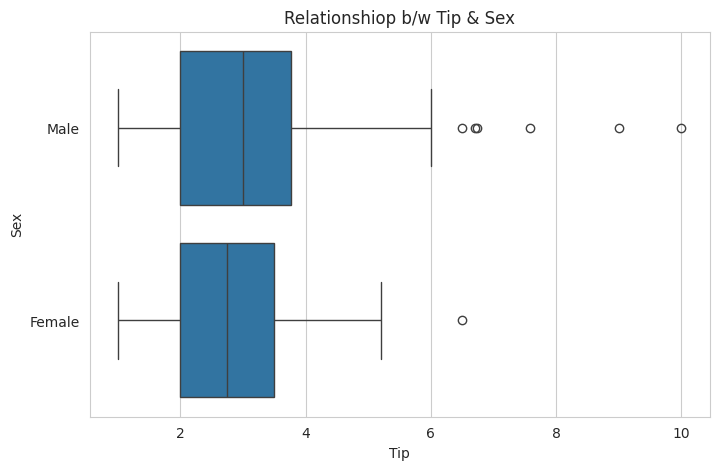

In [41]:
# Checking the relationship of tip vs sex
plt.figure(figsize=(8,5))
sns.boxplot(x='tip', y='sex' , data=df)
plt.title("Relationshiop b/w Tip & Sex")
plt.xlabel("Tip")
plt.ylabel("Sex")
plt.show()

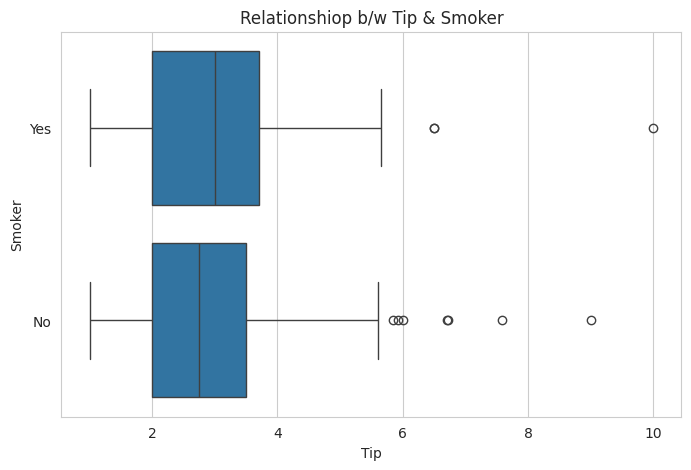

In [42]:
# Checking the relationship of tip vs smoker
plt.figure(figsize=(8,5))
sns.boxplot(x='tip', y='smoker' , data=df)
plt.title("Relationshiop b/w Tip & Smoker")
plt.xlabel("Tip")
plt.ylabel("Smoker")
plt.show()

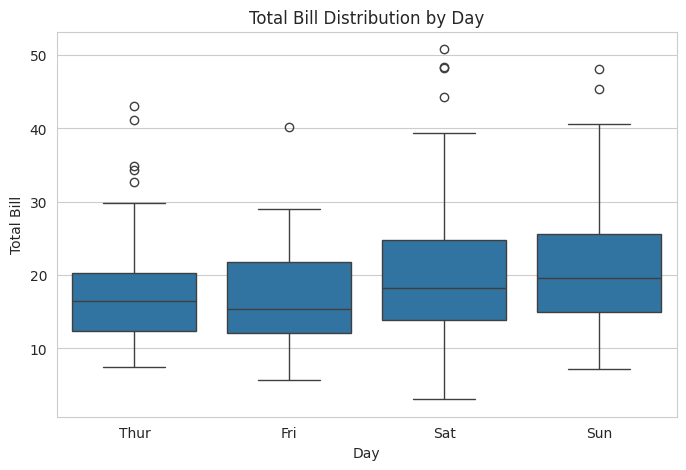

In [43]:
# Checking the relationship of total_bill by day
plt.figure(figsize=(8,5))
sns.boxplot(x="day", y="total_bill", data=df)
plt.title("Total Bill Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")
plt.show()

# CORRELATION HEATMAP

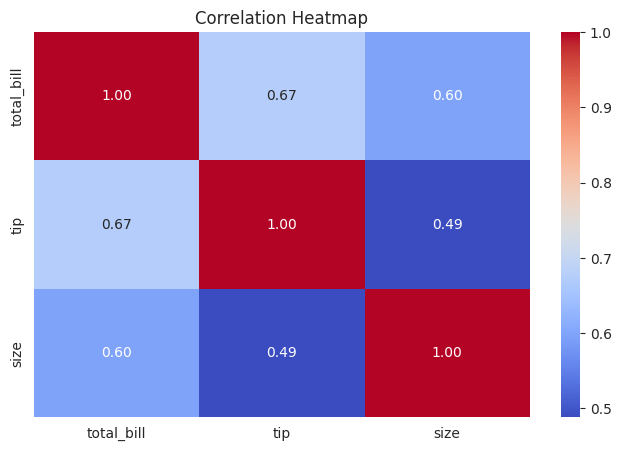

In [45]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

# Final Key Insights

After performing exploratory data analysis on the tips dataset, I found the following key insights:

## 1. Customer Spending Pattern
- The `total_bill` column is positively skewed.
- Most customers had smaller to moderate bill amounts.
- A few customers had very high total bills.

## 2. Customer Tipping Pattern
- The `tip` column is also positively skewed.
- Most customers gave small to moderate tips.
- Only a few customers gave very high tips.

## 3. Gender Distribution
- Male customers were more frequent in the dataset than female customers.

## 4. Smoker Distribution
- Non-smokers were more common than smokers in the dataset.

## 5. Day-wise Customer Visits
- Saturday had the highest number of customers.
- Friday had the lowest number of customers.

## 6. Time-wise Customer Visits
- Dinner had significantly more customers than Lunch.
- This suggests that dinner is the peak business time for the restaurant.

## 7. Relationship Between Bill and Tip
- There is a positive relationship between `total_bill` and `tip`.
- Customers who spend more generally give higher tips.

## 8. Spending Behavior by Day
- Sunday showed higher bill amounts overall.
- Friday showed lower bill amounts.
- Saturday had greater spread and more outliers in bill amounts.

# Project Conclusion

In this project, I performed Exploratory Data Analysis (EDA) on the `tips` dataset using Python, NumPy, Pandas, Matplotlib, and Seaborn.

I explored the dataset by:
- understanding its structure
- checking for missing values and duplicates
- analyzing numerical columns
- analyzing categorical columns
- visualizing relationships between variables
- identifying important patterns and trends

Through this project, I improved my understanding of:
- data cleaning
- univariate analysis
- categorical analysis
- bivariate analysis
- correlation analysis
- data visualization

This project helped me practice the foundational skills required in Data Analysis and Machine Learning.

Overall, this analysis provided useful insight into customer behavior, tipping habits, spending patterns, and restaurant activity trends.